eda

In [5]:
"""
Load a minimum of 6 months of dataset into pandas.
• Explore distributions of ClosePrice (the target variable), LivingArea, Bedrooms,
Bathrooms, LotSize.
• Restrict analysis to PropertyType = Residential and PropertySubType =
SingleFamilyResidence (per task doc).
• Deliverable: Jupyter notebook 01_exploration.ipynb with basic EDA plots.
"""


'\nLoad a minimum of 6 months of dataset into pandas.\n• Explore distributions of ClosePrice (the target variable), LivingArea, Bedrooms,\nBathrooms, LotSize.\n• Restrict analysis to PropertyType = Residential and PropertySubType =\nSingleFamilyResidence (per task doc).\n• Deliverable: Jupyter notebook 01_exploration.ipynb with basic EDA plots.\n'

### 1. data loading

In [6]:
import glob
import pandas as pd

file_paths = glob.glob("data/california/CRMLSSold*.csv")

# Get the columns of the very first file to use as a baseline
base_columns = set(pd.read_csv(file_paths[0], nrows=1).columns)
all_match = True

print("Checking column consistency...")
for file in file_paths[1:]:
    current_columns = set(pd.read_csv(file, nrows=1).columns)
    
    if base_columns != current_columns:
        all_match = False
        missing_in_current = base_columns - current_columns
        extra_in_current = current_columns - base_columns
        
        print(f"\n❌ Mismatch found in file: {file}")
        if missing_in_current:
            print(f"  - Missing columns: {missing_in_current}")
        if extra_in_current:
            print(f"  - Extra columns: {extra_in_current}")

if all_match:
    print("\n✅ Success! All files have identical columns. Safe to concatenate.")

Checking column consistency...

❌ Mismatch found in file: data/california\CRMLSSold202405_filled.csv
  - Missing columns: {'BuyerAgencyCompensationType', 'BuyerAgencyCompensation'}
  - Extra columns: {'BuyerAgentAOR', 'ListAgentAOR'}

❌ Mismatch found in file: data/california\CRMLSSold202406_filled.csv
  - Missing columns: {'BuyerAgencyCompensationType', 'BuyerAgencyCompensation'}
  - Extra columns: {'BuyerAgentAOR', 'ListAgentAOR'}

❌ Mismatch found in file: data/california\CRMLSSold202407_filled.csv
  - Missing columns: {'BuyerAgencyCompensationType', 'BuyerAgencyCompensation'}
  - Extra columns: {'BuyerAgentAOR', 'ListAgentAOR'}

❌ Mismatch found in file: data/california\CRMLSSold202408.csv
  - Missing columns: {'BuyerAgencyCompensationType', 'BuyerAgencyCompensation', 'lonfilled', 'latfilled'}
  - Extra columns: {'BuyerAgentAOR', 'ListAgentAOR'}

❌ Mismatch found in file: data/california\CRMLSSold202409.csv
  - Missing columns: {'BuyerAgencyCompensationType', 'BuyerAgencyCompensati

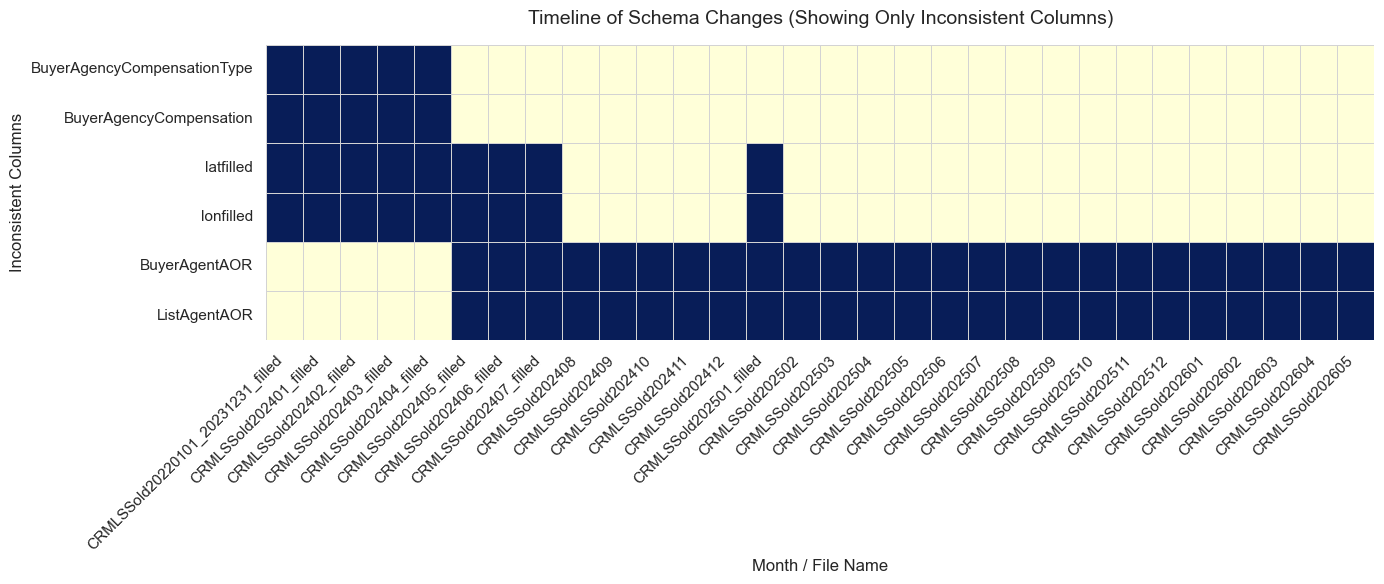

In [7]:
import glob
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Gather files and sort them chronologically
file_paths = sorted(glob.glob("data/california/CRMLSSold*.csv"))

# 2. Extract column presence per month
schema_dict = {}
for file in file_paths:
    # Use the filename (e.g., CRMLSSold202401_filled) as the timeline label
    month_label = os.path.basename(file).replace(".csv", "")
    columns = pd.read_csv(file, nrows=1).columns
    schema_dict[month_label] = {col: 1 for col in columns}

# 3. Create a DataFrame (Rows = Columns, Columns = Months)
# Fill missing columns with 0
df_schema = pd.DataFrame(schema_dict).fillna(0)

# 4. Filter out columns that are perfectly consistent (always 1)
# This keeps the plot clean by only showing columns that change!
changing_columns = df_schema[df_schema.values.sum(axis=1) != len(file_paths)]

# 5. Plot the heatmap
plt.figure(figsize=(14, max(6, len(changing_columns) * 0.4)))
sns.heatmap(
    changing_columns,
    cmap="YlGnBu",
    cbar=False,
    linewidths=0.5,
    linecolor="lightgray",
)
plt.title(
    "Timeline of Schema Changes (Showing Only Inconsistent Columns)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Month / File Name", fontsize=12)
plt.ylabel("Inconsistent Columns", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
import re
df_list = []
for file in file_paths:
    # Extract the 6-digit date string (e.g., '202401') from the filename using regex
    filename = os.path.basename(file)
    match = re.search(r"CRMLSSold(\d{4})(\d{2})", filename)

    if match:
        year = int(match.group(1))
        month = int(match.group(2))
    else:
        # Fallback if filename structure varies slightly
        year = None
        month = None

    # Read the individual CSV
    temp_df = pd.read_csv(file)

    # Inject the engineered time features into this specific batch of data
    temp_df["Year"] = year
    temp_df["Month"] = month
    # Useful as a string format (e.g., "2024-01") for plotting chronological trends later
    temp_df["YearMonth"] = f"{year}-{month:02d}" if year else None

    df_list.append(temp_df)

# 2. Concatenate everything together
df = pd.concat(df_list, axis=0, ignore_index=True)

print("Raw dataset loaded with custom time features!")
print(f"Columns added: 'Year', 'Month', 'YearMonth'")
print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")

C:\Users\CiciA\AppData\Local\Temp\ipykernel_55972\2207501941.py:17: DtypeWarning: Columns (78,79) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)
C:\Users\CiciA\AppData\Local\Temp\ipykernel_55972\2207501941.py:17: DtypeWarning: Columns (2,36,39,56,74) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)
C:\Users\CiciA\AppData\Local\Temp\ipykernel_55972\2207501941.py:17: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)
C:\Users\CiciA\AppData\Local\Temp\ipykernel_55972\2207501941.py:17: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)


Raw dataset loaded with custom time features!
Columns added: 'Year', 'Month', 'YearMonth'
Total Rows: 794271 | Total Columns: 85


### 2. data exploration

In [9]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set plotting style for clean visuals
sns.set_theme(style="whitegrid")

In [10]:
# restrict analysis to Residential - SingleFamilyResidence
df_filtered = df[
    (df["PropertyType"] == "Residential")
    & (df["PropertySubType"] == "SingleFamilyResidence")
].copy()

print(f"Dataset filtered for Residential - SingleFamilyResidence.")
print(
    f"Filtered Rows: {df_filtered.shape[0]} ({df.shape[0] - df_filtered.shape[0]} rows removed)"
)

Dataset filtered for Residential - SingleFamilyResidence.
Filtered Rows: 399157 (395114 rows removed)


In [11]:
# Explore distributions of ClosePrice (the target variable), LivingArea, Bedrooms, Bathrooms, LotSize. 

In [12]:
df_filtered.columns

Index(['Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType',
       'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'Bu

In [20]:
features =  [
    "ClosePrice",
    "LivingArea",
    "LotSizeSquareFeet",
    "LotSizeAcres",
    "BedroomsTotal", 
    "BathroomsTotalInteger"
]
df_filtered[features].describe()

,ClosePrice,LivingArea,LotSizeSquareFeet,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger
count,3.991550e+05,3.989470e+05,3.923310e+05,3.922700e+05,399157.000000,399082.000000
mean,1.285092e+06,2.036718e+03,2.454994e+05,3.159604e+01,3.476710,2.610133
std,5.237207e+06,3.803275e+03,1.387443e+07,1.252249e+04,0.960517,1.182700
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,6.200000e+05,1.373000e+03,5.663000e+03,1.300000e-01,3.000000,2.000000
50%,8.890000e+05,1.800000e+03,7.247000e+03,1.664000e-01,3.000000,2.000000
75%,1.425000e+06,2.417500e+03,1.034000e+04,2.376000e-01,4.000000,3.000000
max,9.895000e+08,2.308680e+06,2.087221e+09,7.810698e+06,45.000000,175.000000


In [14]:
df_filtered[features].value_counts

<bound method DataFrame.value_counts of         ClosePrice  LivingArea  LotSizeSquareFeet  LotSizeAcres  \
3        2499999.0      2645.0            13376.0        0.3071   
6         640000.0      2070.0             3397.0        0.0780   
7         438000.0      1174.0             9900.0        0.2273   
12        615000.0      1996.0             6098.0        0.1400   
14        399990.0      1422.0            12197.0        0.2800   
...            ...         ...                ...           ...   
794237    455000.0      1724.0             2921.0        0.0671   
794239   1850000.0      3000.0          3117589.2       71.5700   
794247    655000.0      1008.0             7039.0        0.1616   
794249  21500000.0     23314.0           935669.0       21.4800   
794267    410000.0      1203.0             5202.0        0.1194   

        BedroomsTotal  BathroomsTotalInteger  
3                 4.0                    4.0  
6                 3.0                    3.0  
7             

--- ClosePrice Stats (Full Data) ---
count        399,155.00
mean       1,285,092.42
std        5,237,206.55
min                0.00
25%          620,000.00
50%          889,000.00
75%        1,425,000.00
max      989,500,000.00
Name: ClosePrice, dtype: object


--- LivingArea Stats (Full Data) ---
count      398,947.00
mean         2,036.72
std          3,803.28
min              0.00
25%          1,373.00
50%          1,800.00
75%          2,417.50
max      2,308,680.00
Name: LivingArea, dtype: object


--- LotSizeSquareFeet Stats (Full Data) ---
count          392,331.00
mean           245,499.36
std         13,874,432.02
min                  0.00
25%              5,663.00
50%              7,247.00
75%             10,340.00
max      2,087,220,960.00
Name: LotSizeSquareFeet, dtype: object


--- LotSizeAcres Stats (Full Data) ---
count      392,270.00
mean            31.60
std         12,522.49
min              0.00
25%              0.13
50%              0.17
75%              0.24
max 

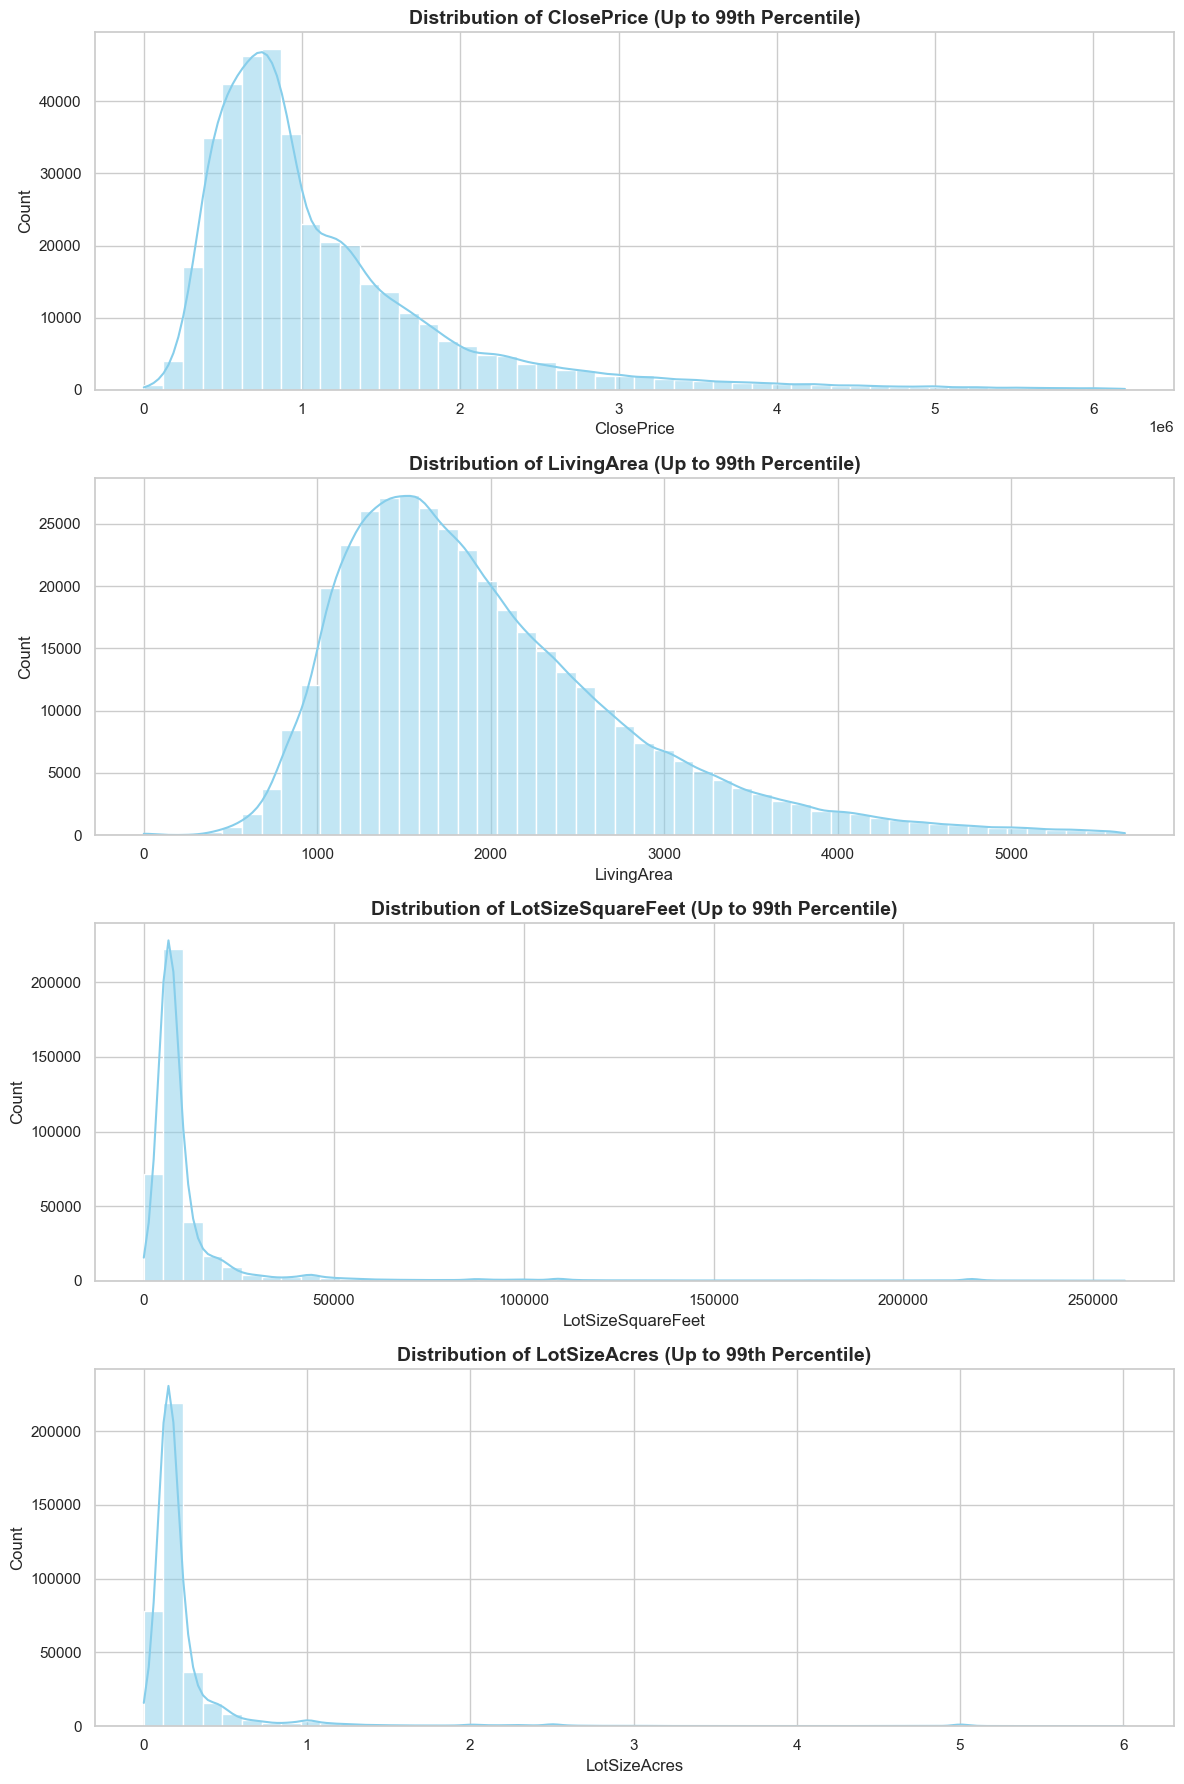

In [15]:
continuous_features = [
    "ClosePrice",
    "LivingArea",
    "LotSizeSquareFeet",
    "LotSizeAcres",
]

fig, axes = plt.subplots(len(continuous_features), 1, figsize=(12, 18))

for i, col in enumerate(continuous_features):
    if col in df_filtered.columns:
        # Drop NaNs just for clean plotting
        plot_data = df_filtered[col].dropna()

        # Filter out extreme outliers dynamically (e.g., top 1%) just so the initial plot is readable
        q_high = plot_data.quantile(0.99)
        plot_data_filtered = plot_data[plot_data <= q_high]

        sns.histplot(
            plot_data_filtered, kde=True, bins=50, ax=axes[i], color="skyblue"
        )
        axes[i].set_title(
            f"Distribution of {col} (Up to 99th Percentile)",
            fontsize=14,
            weight="bold",
        )
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel("Count", fontsize=12)

        print(f"--- {col} Stats (Full Data) ---")
        print(plot_data.describe().apply(lambda x: format(x, ",.2f")))
        print("\n")
    else:
        axes[i].text(
            0.5,
            0.5,
            f"Column '{col}' not found!",
            ha="center",
            va="center",
            fontsize=14,
        )

plt.tight_layout()
plt.show()

--- BedroomsTotal Value Counts ---
BedroomsTotal
0.0        224
1.0       2635
2.0      45511
3.0     169795
4.0     132135
5.0      40106
6.0       6805
7.0       1345
8.0        380
9.0        107
10.0        52
11.0        18
12.0        17
13.0         9
14.0         3
15.0         6
16.0         2
17.0         1
19.0         1
22.0         2
31.0         1
34.0         1
45.0         1
Name: count, dtype: int64


--- BathroomsTotalInteger Value Counts ---
BathroomsTotalInteger
0.0         167
1.0       38314
2.0      173048
3.0      132361
4.0       32239
5.0       13927
6.0        5467
7.0        1959
8.0         805
9.0         384
10.0        174
11.0         91
12.0         59
13.0         29
14.0         17
15.0         11
16.0          6
17.0          2
18.0          4
20.0          4
21.0          2
22.0          2
23.0          1
24.0          1
25.0          1
27.0          2
31.0          1
35.0          1
45.0          1
153.0         1
175.0         1
Name: count, dtyp

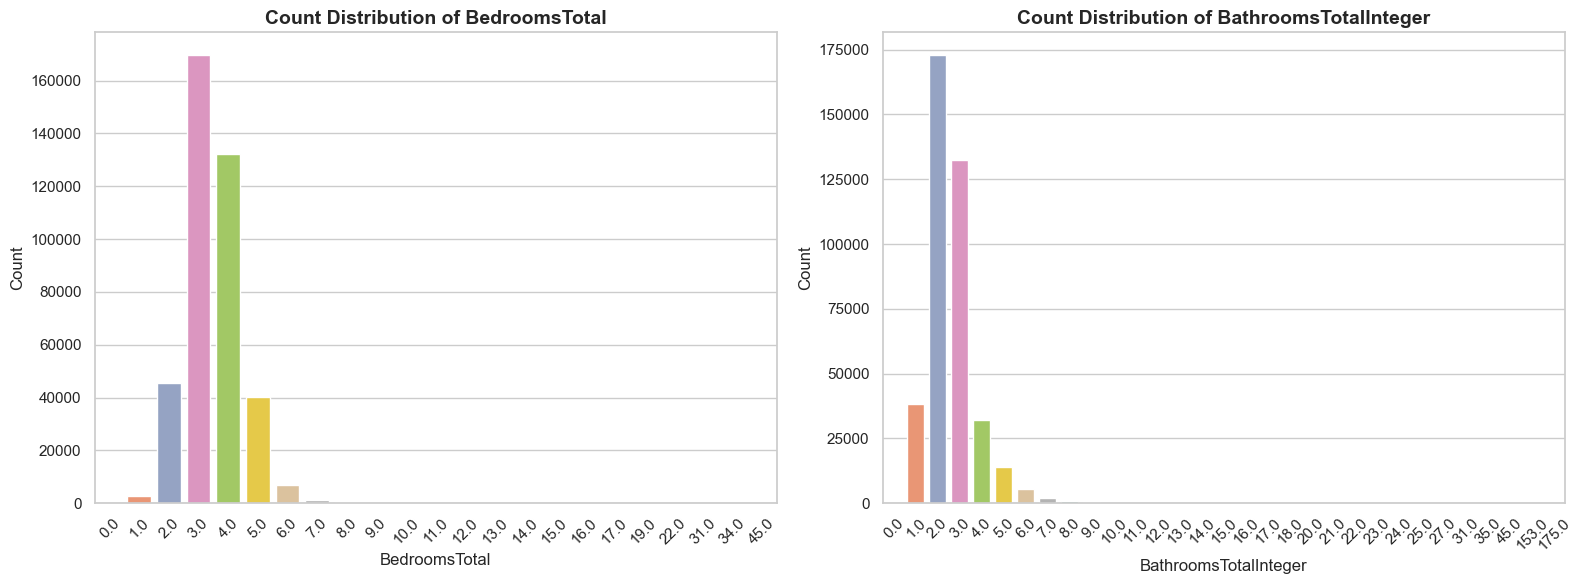

In [16]:
discrete_features = ["BedroomsTotal", "BathroomsTotalInteger"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, col in enumerate(discrete_features):
    if col in df_filtered.columns:
        # Get value counts and plot a clean bar chart
        sns.countplot(
            data=df_filtered,
            x=col,
            ax=axes[i],
            palette="Set2",
            hue=col,
            legend=False,
        )
        axes[i].set_title(
            f"Count Distribution of {col}", fontsize=14, weight="bold"
        )
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel("Count", fontsize=12)
        axes[i].tick_params(axis="x", rotation=45)

        print(f"--- {col} Value Counts ---")
        print(df_filtered[col].value_counts().sort_index())
        print("\n")
    else:
        axes[i].text(
            0.5,
            0.5,
            f"Column '{col}' not found!",
            ha="center",
            va="center",
            fontsize=14,
        )

plt.tight_layout()
plt.show()

In [19]:
df_filtered.columns

Index(['Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType',
       'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'Bu

In [21]:
selected = features + ['Year','Month','YearMonth']
df_selected = df_filtered[selected]

In [22]:
df_selected.head(10)

,ClosePrice,LivingArea,LotSizeSquareFeet,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,Year,Month,YearMonth
3,2499999.0,2645.0,13376.0,0.3071,4.0,4.0,2022,1,2022-01
6,640000.0,2070.0,3397.0,0.0780,3.0,3.0,2022,1,2022-01
7,438000.0,1174.0,9900.0,0.2273,3.0,2.0,2022,1,2022-01
12,615000.0,1996.0,6098.0,0.1400,2.0,2.0,2022,1,2022-01
14,399990.0,1422.0,12197.0,0.2800,3.0,2.0,2022,1,2022-01
16,1050000.0,1312.0,7152.0,0.1642,3.0,2.0,2022,1,2022-01
21,1839270.0,3773.0,7570.0,0.1738,6.0,4.0,2022,1,2022-01
22,400000.0,1574.0,7200.0,0.1600,3.0,2.0,2022,1,2022-01
23,275000.0,1578.0,28125.0,0.6457,4.0,1.0,2022,1,2022-01
24,2000000.0,3226.0,7492.0,0.1720,5.0,3.0,2022,1,2022-01


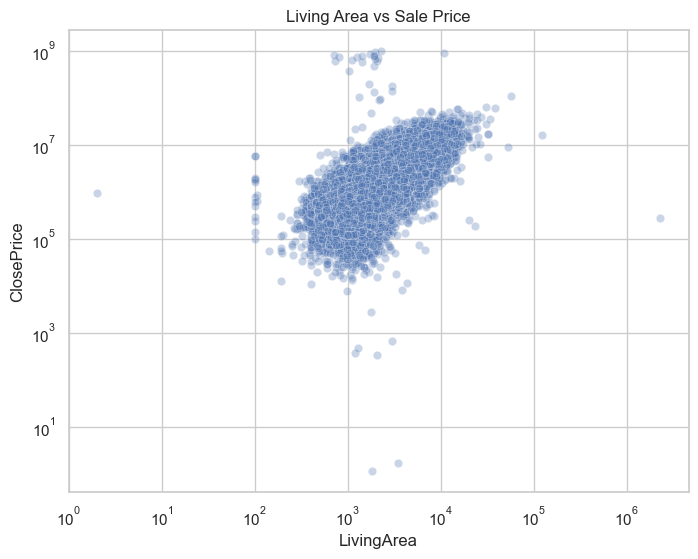

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_selected,
    x="LivingArea",
    y="ClosePrice",
    alpha=0.3
)
plt.xscale('log')
plt.yscale('log')

plt.title("Living Area vs Sale Price")
plt.show()

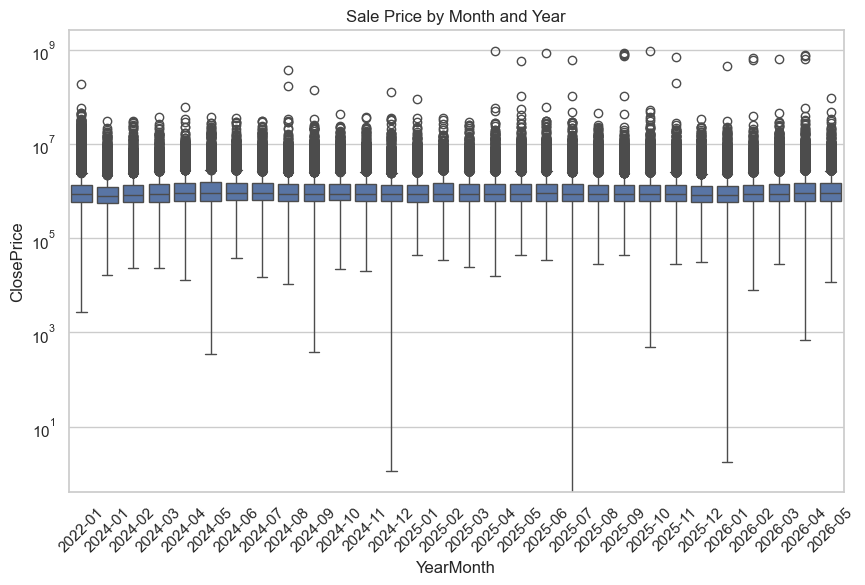

In [32]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_selected,
    x="YearMonth",
    y="ClosePrice"
)

plt.xticks(rotation=45)
plt.yscale('log')
plt.title("Sale Price by Month and Year")
plt.show()

<Axes: xlabel='Year'>

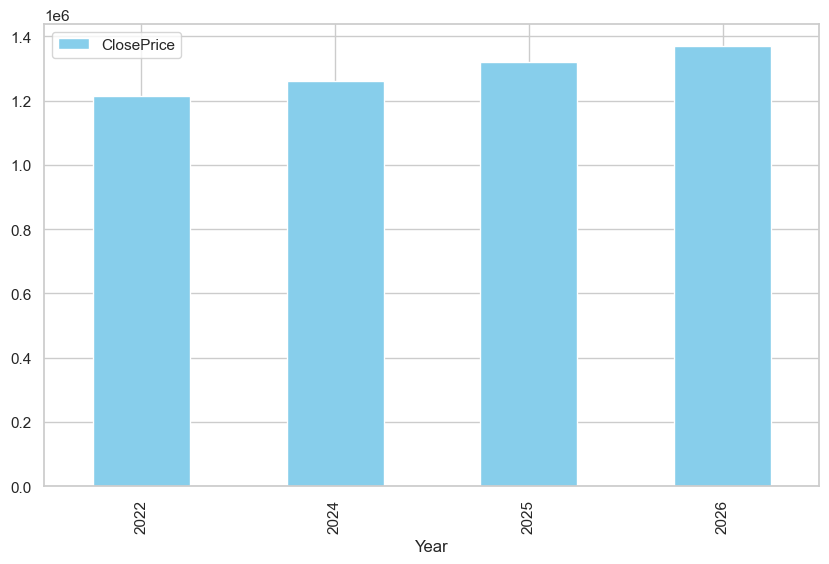

In [35]:
df_selected.drop(columns=['YearMonth']).groupby('Year').mean().reset_index().plot(x='Year', y='ClosePrice', kind='bar', figsize=(10,6), color='skyblue')